<a href="https://colab.research.google.com/github/supakit-kos/CV-Project-Pneumonia/blob/main/CV_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dowload libary

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
import cv2
from tqdm import tqdm

# Dowload RSNA Pneumonia Dataset

In [2]:
DATA_PATH = "/Users/supakitkositsmith/Downloads/rsna-pneumonia-detection-challenge"

In [3]:
os.listdir(DATA_PATH)

['stage_2_test_images',
 'stage_2_detailed_class_info.csv',
 'stage_2_sample_submission.csv',
 'stage_2_train_images',
 'GCP Credits Request Link - RSNA.txt',
 'stage_2_train_labels.csv']

In [4]:
DATA_PATH = "/Users/supakitkositsmith/Downloads/rsna-pneumonia-detection-challenge"

train_images_path = os.path.join(DATA_PATH, "stage_2_train_images")
test_images_path = os.path.join(DATA_PATH, "stage_2_test_images")

labels_path = os.path.join(DATA_PATH, "stage_2_train_labels.csv")
class_info_path = os.path.join(DATA_PATH, "stage_2_detailed_class_info.csv")

# Data Exploration

In [5]:
# Load labels
labels = pd.read_csv(labels_path)
labels.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [6]:
#Load class_info
class_info = pd.read_csv(class_info_path)
class_info.head()

,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


In [7]:
#Check number of image
train_images = os.listdir(train_images_path)
test_images = os.listdir(test_images_path)

print("Train images:", len(train_images))
print("Test images:", len(test_images))

Train images: 26684
Test images: 3000


In [8]:
#Check unique patients
print("Unique patients:", labels.patientId.nunique())

Unique patients: 26684


In [9]:
#Check class distribute
class_info['class'].value_counts()

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

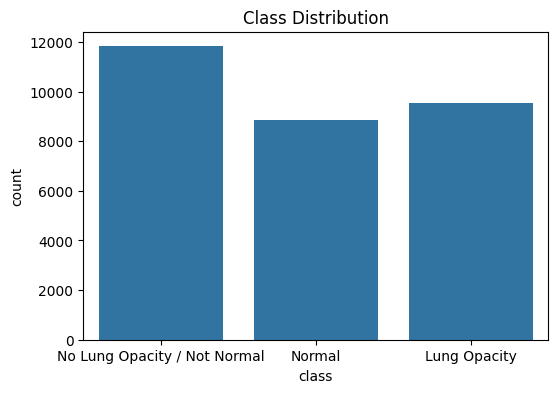

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=class_info)
plt.title("Class Distribution")
plt.show()

# Lung Opacity = คนที่เป็น Pneumonia
# Normal/No lung Opacity = คนที่ไม่เป็น lung opacity

In [11]:
#Check pneumonia vs normal
labels['Target'].value_counts()

# 0 = ไม่เป็น pneumonia
# 1 = เป็น pneumonia

# Class imbalance เล็กน้อย

Target
0    20672
1     9555
Name: count, dtype: int64

In [12]:
#Check bounding box
labels.groupby("patientId").size().value_counts()

#หมายความว่าคนส่วนใหญ่จำนวน 23286 คนมี Pneumonia 1 จุด

1    23286
2     3266
3      119
4       13
Name: count, dtype: int64

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

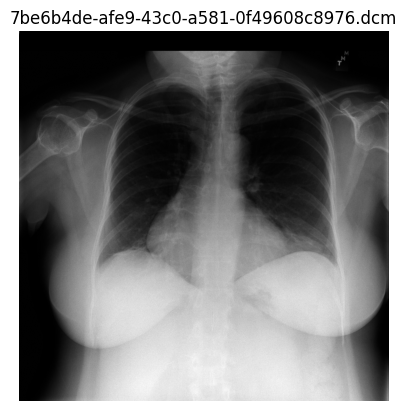

In [16]:
#Check example image
sample = train_images[0]

file_path = os.path.join(train_images_path, sample)

ds = pydicom.dcmread(file_path)

img = ds.pixel_array

plt.imshow(img, cmap='gray')
plt.title(sample)
plt.axis("off")

In [17]:
#Check image size of example image
img.shape

(1024, 1024)

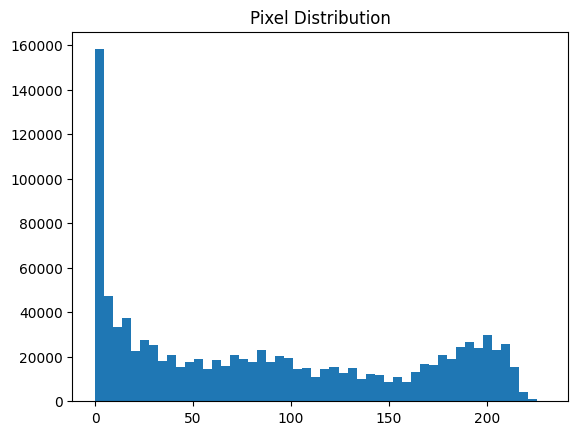

In [18]:
#pixel distribution
plt.hist(img.flatten(), bins=50)
plt.title("Pixel Distribution")
plt.show()

# pixel ส่วนใหญ่ประมาณ 80-180 รูปเป็น gray-scale

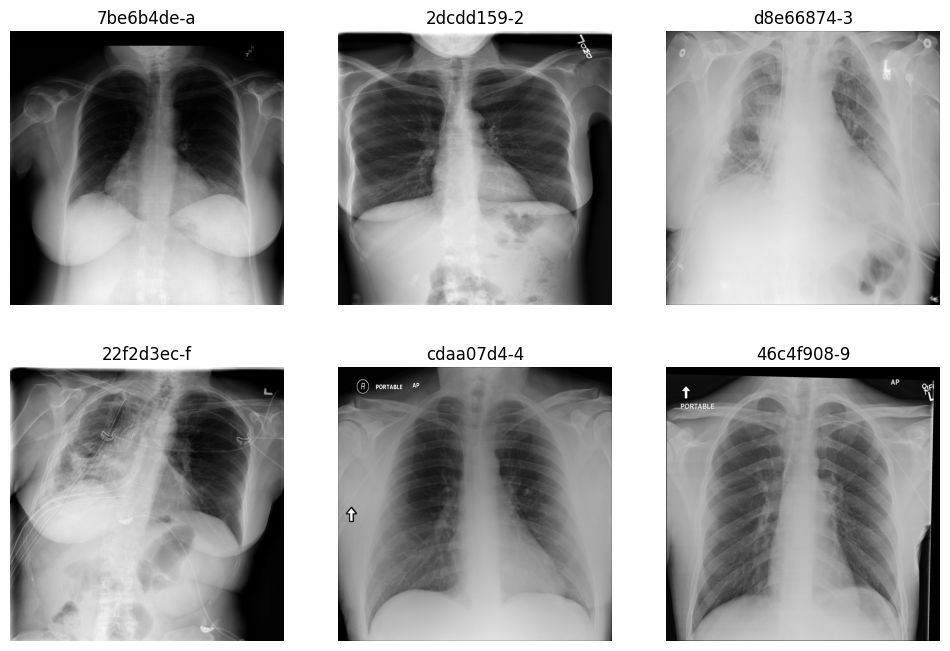

In [19]:
#Check image
plt.figure(figsize=(12,8))

for i in range(6):

    file = train_images[i]

    ds = pydicom.dcmread(os.path.join(train_images_path, file))
    img = ds.pixel_array

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(file[:10])
    plt.axis("off")

plt.show()

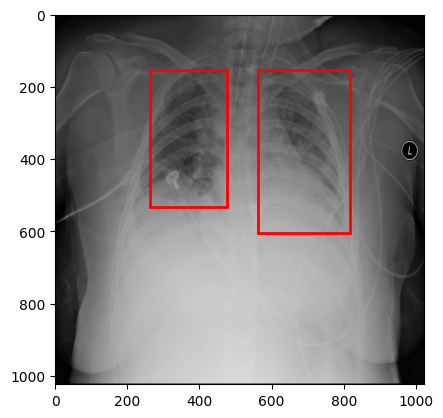

In [20]:
# Overlay bounding boxes
patient = labels[labels.Target == 1].patientId.values[0]

file_path = os.path.join(train_images_path, patient + ".dcm")

ds = pydicom.dcmread(file_path)
img = ds.pixel_array

boxes = labels[labels.patientId == patient]

fig, ax = plt.subplots(1)
ax.imshow(img, cmap='gray')

for _, row in boxes.iterrows():

    x = row['x']
    y = row['y']
    w = row['width']
    h = row['height']

    rect = plt.Rectangle((x,y), w, h,
                         fill=False,
                         color='red',
                         linewidth=2)

    ax.add_patch(rect)

plt.show()

In [21]:
#Check size of all images
sizes = []

for file in tqdm(train_images[:500]):

    ds = pydicom.dcmread(os.path.join(train_images_path, file))
    img = ds.pixel_array

    sizes.append(img.shape)

pd.Series(sizes).value_counts()

#รูปส่วนใหญ่มี size 1024 x 1024

100%|██████████| 500/500 [00:01<00:00, 387.15it/s]


(1024, 1024)    500
Name: count, dtype: int64

# Convert DCM to PNG

In [22]:
#Create folder
output_dir = "/Users/supakitkositsmith/Downloads/rsna-images"

os.makedirs(output_dir, exist_ok=True)

In [ ]:
# #Convert & Resize Train,valid Error handling
IMG_SIZE = 512

for file in tqdm(train_images):

    try:

         path = os.path.join(train_images_path, file)

         ds = pydicom.dcmread(path)
         img = ds.pixel_array

         img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
         img = img.astype("uint8")

         img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

         save_path = os.path.join(output_dir, file.replace(".dcm",".png"))

         cv2.imwrite(save_path, img)

    except:
         print("error:", file)

100%|██████████| 26684/26684 [02:14<00:00, 198.36it/s]


# Train Valid split

In [24]:
from sklearn.model_selection import train_test_split

patients = labels.patientId.unique()

train_ids, val_ids = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_ids))
print("Validation:", len(val_ids))

Train: 21347
Validation: 5337


Dowload split train,valid dataset

In [27]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# path รูปที่ convert แล้ว
image_dir = "/Users/supakitkositsmith/Downloads/rsna-images"

# path labels
labels = pd.read_csv(labels_path)

# split by patient
patients = labels.patientId.unique()

train_ids, val_ids = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

# สร้าง folder
base_dir = "/Users/supakitkositsmith/Downloads/dataset"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "valid")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# copy train images
for pid in tqdm(train_ids):
    src = os.path.join(image_dir, f"{pid}.png")
    dst = os.path.join(train_dir, f"{pid}.png")
    
    if os.path.exists(src):
        shutil.copy(src, dst)

# copy validation images
for pid in tqdm(val_ids):
    src = os.path.join(image_dir, f"{pid}.png")
    dst = os.path.join(val_dir, f"{pid}.png")
    
    if os.path.exists(src):
        shutil.copy(src, dst)

print("Finished splitting dataset!")

100%|██████████| 5337/5337 [00:02<00:00, 1887.29it/s]

Finished splitting dataset!


Convert,Resize,Download test to dataset

In [35]:
import os
import cv2
import pydicom
from tqdm import tqdm

# folder dataset หลัก
dataset_path = "/Users/supakitkositsmith/Downloads/dataset-pneumonia"

# folder test
test_output_path = os.path.join(dataset_path, "test")

# สร้าง folder
os.makedirs(test_output_path, exist_ok=True)

for file in tqdm(os.listdir(test_images_path)):
    
    dicom = pydicom.dcmread(os.path.join(test_images_path, file))
    
    img = dicom.pixel_array
    
    img = cv2.resize(img, (512,512))
    
    save_path = os.path.join(
        test_output_path,
        file.replace(".dcm",".png")
    )
    
    cv2.imwrite(save_path, img)

print("Test conversion finished!")

100%|██████████| 3000/3000 [00:15<00:00, 199.38it/s]

Test conversion finished!
